# ============================================
# 📊 Hopify Retention Curve (8 Segments)
# ============================================

# ================================
# 📁 Set Base Path to Project Root
# ================================

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ================================
# 📁 Set Base Path to Project Root
# ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ================================
## 📥 Load & Clean Data
## ================================

In [2]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "01_project_churn_retention_analysis",
    "07_hopify_retention_curve_signup_cohort.csv"
)

df = pd.read_csv(file_path)

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("%", "percent")
    .str.replace("-", "_")
    .str.lower()
)

# Parse cohort month and sort
df['signup_cohort_month'] = pd.to_datetime(df['signup_cohort_month'], format="%Y-%m")
df = df.sort_values(['customer_segment', 'signup_cohort_month', 'months_since_signup'])

# ===============================================
# 🔍 Filter to 8 Most Recent Cohorts per Segment
# ===============================================

In [3]:
recent_cohorts = (
    df[['customer_segment', 'signup_cohort_month']]
    .drop_duplicates()
    .groupby('customer_segment', group_keys=False)
    .apply(lambda x: x.nlargest(8, 'signup_cohort_month'))
    .reset_index(drop=True)
)

filtered_df = df.merge(recent_cohorts, on=['customer_segment', 'signup_cohort_month'])

# Create readable label for legend
filtered_df['cohort_label'] = filtered_df['signup_cohort_month'].dt.strftime('%Y-%m')


/var/folders/z4/bhxvrvmn0n30jr8zdx9wy1x80000gn/T/ipykernel_31229/3173018440.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(8, 'signup_cohort_month'))


# ============================================
# Plot Retention Curve (Faceted by Segment)
# ============================================

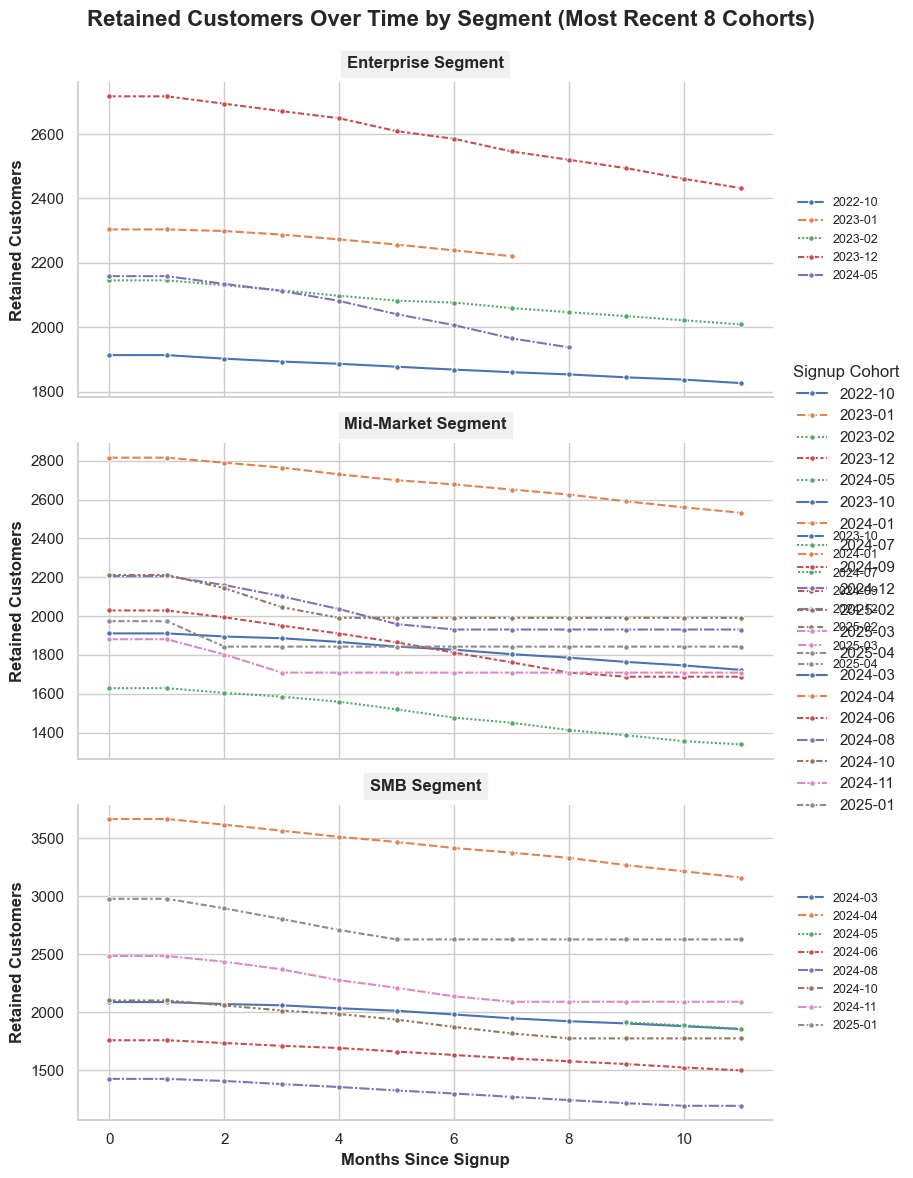

In [4]:
sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    filtered_df,
    col='customer_segment',
    col_wrap=1,
    height=4,
    aspect=2,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x='months_since_signup',
    y='remaining_active_customers',
    hue='cohort_label',
    style='cohort_label',
    marker='o',
    linewidth=1.5,
    markersize=4
)

# External legend formatting
g.add_legend(title='Signup Cohort')
for ax in g.axes.flatten():
    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=9,
        title_fontsize=10
    )

# Titles and formatting
g.set_titles("{col_name} Segment")
g.set_axis_labels("Months Since Signup", "Retained Customers", fontweight='bold')
g.fig.suptitle("Retained Customers Over Time by Segment (Most Recent 8 Cohorts)", fontsize=16, weight='bold')

# Style facet headers
for ax in g.axes.flatten():
    title = ax.get_title()
    ax.set_title(title, fontsize=12, weight='bold', backgroundcolor='#f0f0f0', pad=10)

plt.tight_layout()
plt.subplots_adjust(top=0.92, right=0.85)